# Market Regime Classification: EDA & Data Loading

## Project Objective
Build a classifier that predicts **market regime** (Expansion → Late Cycle → Contraction → Recovery) from price and macro data.

### Why This Matters
- Different regimes require different portfolio strategies
- Early regime detection = alpha opportunity
- Forces us to think about feature engineering, time-series validation, and interpretability

### Data We'll Use
- **Price**: SPY (2011-present, 15 years)
- **Volatility**: Computed from SPY returns
- **Macro**: Unemployment, CPI, yield curve, inflation, oil
- **Validation**: Walk-forward time-series CV (no lookahead bias)


## Setup: Imports & Config

In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths: notebook is in projects/ml/1_market_regime_model/
# Go up 3 levels to wealth-platform, then down to data
DB_PATH = Path('../../../data/investing/investing.duckdb').resolve()
PROJECT_DIR = Path('.')

print(f"Database: {DB_PATH}")
print(f"Database exists: {DB_PATH.exists()}")
print(f"Project: {PROJECT_DIR}")

Database: /Users/timsayers/wealth-platform/data/investing/investing.duckdb
Database exists: True
Project: .


## Part 1: Load SPY Price Data

SPY is our primary signal—it's a broad market index, so it captures regime shifts.

**What we're loading:**
- Daily closing prices
- Daily returns (already computed)
- Date range: 2011-01-03 to present

In [4]:
conn = duckdb.connect(str(DB_PATH))

# Load SPY from silver_macro_prices
query_spy = """
SELECT 
    date,
    close as spy_price,
    ret_1d as spy_ret_1d
FROM silver_macro_prices
WHERE symbol = 'SPY'
ORDER BY date ASC
"""

spy_df = conn.execute(query_spy).fetchdf()

# Convert date to datetime
spy_df['date'] = pd.to_datetime(spy_df['date'])

print(f"SPY data shape: {spy_df.shape}")
print(f"Date range: {spy_df['date'].min()} to {spy_df['date'].max()}")
print(f"\\nFirst 5 rows:")
print(spy_df.head())
print(f"\\nLast 5 rows:")
print(spy_df.tail())

SPY data shape: (3847, 3)
Date range: 2011-01-03 00:00:00 to 2026-04-21 00:00:00
\nFirst 5 rows:
        date  spy_price  spy_ret_1d
0 2011-01-03  96.928169         NaN
1 2011-01-04  96.874748   -0.000551
2 2011-01-05  97.378334    0.005198
3 2011-01-06  97.187569   -0.001959
4 2011-01-07  96.996826   -0.001963
\nLast 5 rows:
           date   spy_price  spy_ret_1d
3842 2026-04-15  699.940002         NaN
3843 2026-04-16  701.659973         NaN
3844 2026-04-17  710.140015         NaN
3845 2026-04-20  708.719971         NaN
3846 2026-04-21  704.080017         NaN


### Compute Additional Price Features

From daily prices, we'll compute:
- **Multi-period returns** (5d, 20d, 60d) → momentum
- **Rolling volatility** (20d, 60d) → risk/regime signal

Why these windows?
- 20d = 1 month = short-term momentum
- 60d = 3 months = intermediate trend
- 5d = 1 week = noise filter

In [5]:
# Compute log returns (more stable than simple returns)
spy_df['log_ret'] = np.log(spy_df['spy_price'] / spy_df['spy_price'].shift(1))

# Multi-period returns
spy_df['ret_5d'] = (spy_df['spy_price'] / spy_df['spy_price'].shift(5) - 1) * 100  # % return
spy_df['ret_20d'] = (spy_df['spy_price'] / spy_df['spy_price'].shift(20) - 1) * 100
spy_df['ret_60d'] = (spy_df['spy_price'] / spy_df['spy_price'].shift(60) - 1) * 100

# Rolling volatility (annualized)
spy_df['vol_20d'] = spy_df['log_ret'].rolling(20).std() * np.sqrt(252) * 100  # % annualized
spy_df['vol_60d'] = spy_df['log_ret'].rolling(60).std() * np.sqrt(252) * 100

print("Price features computed:")
print(spy_df[['date', 'spy_price', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d']].tail(10))

Price features computed:
           date   spy_price   ret_20d   ret_60d    vol_20d    vol_60d
3837 2026-04-08  676.010010  0.099858 -2.336043  20.295165  15.278525
3838 2026-04-09  679.909973  0.803869 -1.926631  20.387618  15.325465
3839 2026-04-10  679.460022  2.290434 -1.795176  19.536729  15.321662
3840 2026-04-13  686.099976  3.878017 -0.345654  19.589673  15.426628
3841 2026-04-14  694.460022  4.084505  0.594681  19.712528  15.617732
3842 2026-04-15  699.940002  4.630598  1.473495  19.821763  15.696974
3843 2026-04-16  701.659973  6.371985  3.836627  18.862546  15.090681
3844 2026-04-17  710.140015  7.923524  3.892532  18.996707  15.107601
3845 2026-04-20  708.719971  9.274244  3.146026  17.892671  15.086635
3846 2026-04-21  704.080017  7.430805  2.433573  18.151952  15.156359


## Part 2: Load Macro & Regime Signals

**Economic indicators** tell us what phase of the cycle we're in:
- **Unemployment**: Rising = contraction, falling = expansion/recovery
- **Inflation (CPI)**: Hot inflation = late cycle, cooling = contraction/recovery
- **Yield curve**: Inverted (10Y < 2Y) = recession risk, steep = expansion
- **Oil prices**: Energy demand signal + inflation hedge

In [6]:
# Load economic indicators
query_econ = """
SELECT 
    date,
    name,
    value
FROM silver_economic_indicators
WHERE name IN ('unemploymentRate', 'CPI', 'inflationRate', 'GDP')
ORDER BY date ASC
"""

econ_df = conn.execute(query_econ).fetchdf()
econ_df['date'] = pd.to_datetime(econ_df['date'])

# Pivot to get each indicator as a column
econ_pivot = econ_df.pivot(index='date', columns='name', values='value').reset_index()

print(f"Economic indicators shape: {econ_pivot.shape}")
print(f"Indicators available: {econ_pivot.columns.tolist()}")
print(f"\\nFirst 5 rows (note: economic data is monthly):")
print(econ_pivot.head())
print(f"\\nData frequency: {econ_pivot['date'].diff().dt.days.describe()}")

Economic indicators shape: (718, 5)
Indicators available: ['date', 'CPI', 'GDP', 'inflationRate', 'unemploymentRate']
\nFirst 5 rows (note: economic data is monthly):
name       date    CPI       GDP  inflationRate  unemploymentRate
0    1990-01-01  127.5  5872.701            NaN               5.4
1    1990-02-01  128.0       NaN            NaN               5.3
2    1990-03-01  128.6       NaN            NaN               5.2
3    1990-04-01  128.9  5960.028            NaN               5.4
4    1990-05-01  129.1       NaN            NaN               5.4
\nData frequency: count    717.000000
mean      18.486750
std       14.305189
min        1.000000
25%        1.000000
50%       30.000000
75%       31.000000
max       31.000000
Name: date, dtype: float64


In [7]:
# Load treasury yield curve
query_treasury = """
SELECT 
    date,
    y2,
    y10
FROM silver_treasury_rates
ORDER BY date ASC
"""

treasury_df = conn.execute(query_treasury).fetchdf()
treasury_df['date'] = pd.to_datetime(treasury_df['date'])
treasury_df['yield_curve_spread'] = treasury_df['y10'] - treasury_df['y2']

print(f"Treasury data shape: {treasury_df.shape}")
print(f"\\nLast 5 rows:")
print(treasury_df[['date', 'y2', 'y10', 'yield_curve_spread']].tail())

Treasury data shape: (9080, 4)
\nLast 5 rows:
           date    y2   y10  yield_curve_spread
9075 2026-04-14  3.76  4.26                0.50
9076 2026-04-15  3.76  4.29                0.53
9077 2026-04-16  3.78  4.32                0.54
9078 2026-04-17  3.71  4.26                0.55
9079 2026-04-20  3.72  4.26                0.54


In [8]:
# Load oil futures (energy/inflation signal)
query_oil = """
SELECT 
    date,
    close as oil_price
FROM silver_macro_prices
WHERE symbol = 'CL=F'  -- Crude oil futures
ORDER BY date ASC
"""

oil_df = conn.execute(query_oil).fetchdf()
oil_df['date'] = pd.to_datetime(oil_df['date'])

# Compute oil momentum
oil_df['oil_ret_20d'] = (oil_df['oil_price'] / oil_df['oil_price'].shift(20) - 1) * 100

print(f"Oil data shape: {oil_df.shape}")
print(f"\\nLast 5 rows:")
print(oil_df.tail())

Oil data shape: (3847, 3)
\nLast 5 rows:
           date  oil_price  oil_ret_20d
3842 2026-04-15  90.839996    -5.581543
3843 2026-04-16  89.879997    -6.686049
3844 2026-04-17  84.000000   -12.627418
3845 2026-04-20  86.410004   -12.113503
3846 2026-04-21  90.419998     2.598435


## Part 3: Merge All Data into Master DataFrame

**Challenge:** Economic indicators are monthly, price data is daily.

**Solution:** Forward-fill economic data (assume unchanged until next release). This is standard practice.

Then drop rows with NaNs (startup period before all indicators exist).

In [9]:
# Start with daily SPY data
regime_data = spy_df[['date', 'spy_price', 'spy_ret_1d', 'ret_5d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d']].copy()

# Merge treasury (daily)
regime_data = regime_data.merge(treasury_df[['date', 'y2', 'y10', 'yield_curve_spread']], on='date', how='left')

# Merge oil (daily)
regime_data = regime_data.merge(oil_df[['date', 'oil_price', 'oil_ret_20d']], on='date', how='left')

# Merge economic (monthly) - forward fill to daily
regime_data = regime_data.merge(econ_pivot, on='date', how='left')
regime_data['unemploymentRate'] = regime_data['unemploymentRate'].ffill()
regime_data['CPI'] = regime_data['CPI'].ffill()
regime_data['inflationRate'] = regime_data['inflationRate'].ffill()
regime_data['GDP'] = regime_data['GDP'].ffill()

# Drop startup period (before all features are available)
regime_data = regime_data.dropna(subset=['vol_20d', 'yield_curve_spread', 'unemploymentRate']).reset_index(drop=True)

print(f"Final dataset shape: {regime_data.shape}")
print(f"Date range: {regime_data['date'].min()} to {regime_data['date'].max()}")
print(f"\nColumns: {regime_data.columns.tolist()}")
print(f"\nSample rows (every 100 days):")
print(regime_data[::100][['date', 'spy_price', 'vol_20d', 'yield_curve_spread', 'unemploymentRate']].head(10))

Final dataset shape: (3798, 17)
Date range: 2011-02-01 00:00:00 to 2026-04-20 00:00:00

Columns: ['date', 'spy_price', 'spy_ret_1d', 'ret_5d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 'y2', 'y10', 'yield_curve_spread', 'oil_price', 'oil_ret_20d', 'CPI', 'GDP', 'inflationRate', 'unemploymentRate']

Sample rows (every 100 days):
          date   spy_price    vol_20d  yield_curve_spread  unemploymentRate
0   2011-02-01   99.743340  11.061253                2.87               9.0
100 2011-06-24   97.647064  15.961220                2.53               9.1
200 2011-11-17   94.514389  30.164723                1.69               8.6
300 2012-04-13  107.289131  13.013280                1.75               8.2
400 2012-09-05  110.809692   5.788873                1.35               8.1
500 2013-02-04  119.062408   7.667323                1.75               7.7
600 2013-06-27  129.502563  18.052011                2.13               7.5
700 2013-11-20  144.182922   8.957957                2.52   

## Part 4: Exploratory Visualizations

Before we build a model, let's see what the regime signals look like. Can we spot recessions visually?

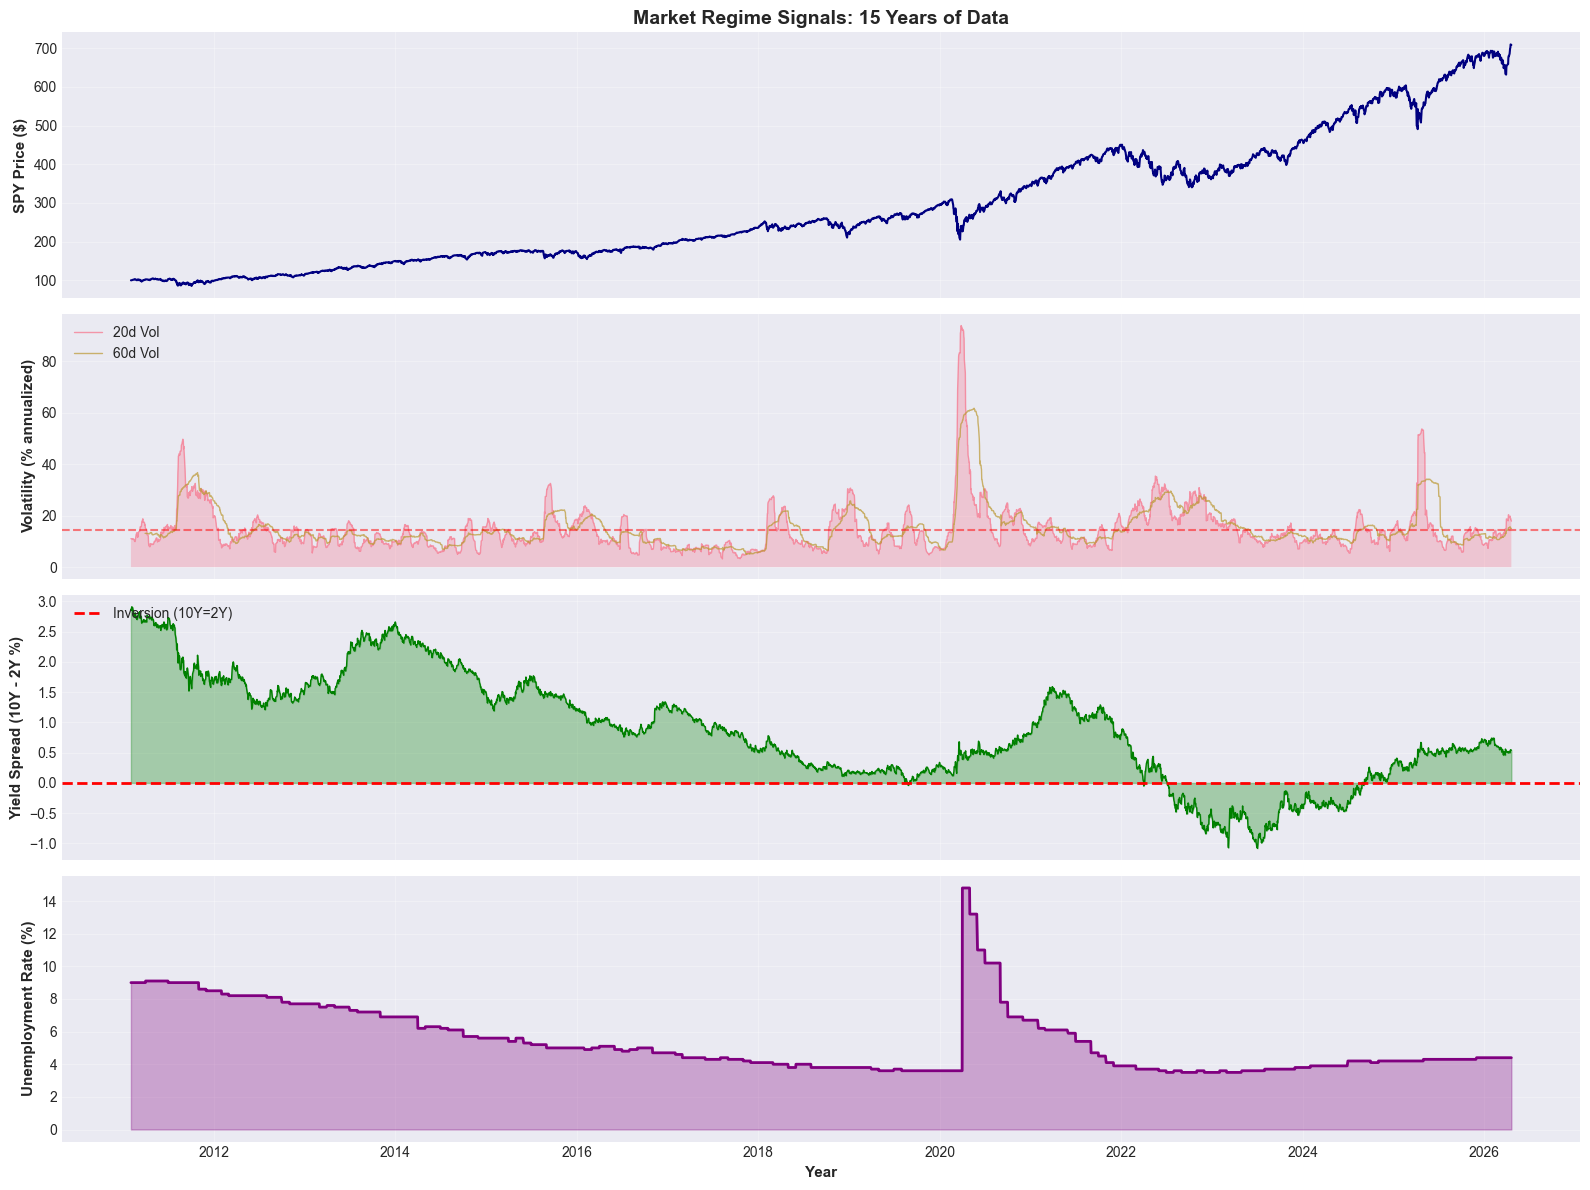

✓ Plot saved to outputs/01_regime_signals_overview.png


In [14]:
# Create output directory if it doesn't exist
import os
os.makedirs('../outputs', exist_ok=True)

# Create a 4-panel plot: Price, Volatility, Yield Curve, Unemployment
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Panel 1: SPY Price
axes[0].plot(regime_data['date'], regime_data['spy_price'], linewidth=1.5, color='navy')
axes[0].set_ylabel('SPY Price ($)', fontsize=11, fontweight='bold')
axes[0].set_title('Market Regime Signals: 15 Years of Data', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Panel 2: Volatility
axes[1].plot(regime_data['date'], regime_data['vol_20d'], linewidth=1, label='20d Vol', alpha=0.7)
axes[1].plot(regime_data['date'], regime_data['vol_60d'], linewidth=1, label='60d Vol', alpha=0.7)
axes[1].fill_between(regime_data['date'], regime_data['vol_20d'], alpha=0.3)
axes[1].set_ylabel('Volatility (% annualized)', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=regime_data['vol_20d'].mean(), color='red', linestyle='--', alpha=0.5, label='Mean')

# Panel 3: Yield Curve Spread
axes[2].plot(regime_data['date'], regime_data['yield_curve_spread'], linewidth=1, color='green')
axes[2].fill_between(regime_data['date'], regime_data['yield_curve_spread'], alpha=0.3, color='green')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Inversion (10Y=2Y)')
axes[2].set_ylabel('Yield Spread (10Y - 2Y %)', fontsize=11, fontweight='bold')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

# Panel 4: Unemployment
axes[3].plot(regime_data['date'], regime_data['unemploymentRate'], linewidth=2, color='purple')
axes[3].fill_between(regime_data['date'], regime_data['unemploymentRate'], alpha=0.3, color='purple')
axes[3].set_ylabel('Unemployment Rate (%)', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../1_market_regime_model/outputs/01_regime_signals_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to outputs/01_regime_signals_overview.png")

## Key Observations

Look at the plots above. What can you spot?

1. **COVID crash (Mar 2020)**: Spike in volatility, inverted yield curve, unemployment spike
2. **2018 slowdown**: Yield curve inverted, volatility rose
3. **2015 China concerns**: Brief vol spike
4. **2008 financial crisis**: Massive unemployment spike, severe vol, inverted curve

These are regimes! The question is: **Can we predict them from the features?**

In [11]:
# Summary statistics
print("=" * 80)
print("FEATURE SUMMARY STATISTICS")
print("=" * 80)

summary_cols = ['spy_price', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_60d', 
                'yield_curve_spread', 'unemploymentRate', 'oil_price']
print(regime_data[summary_cols].describe().round(2))

print("\\n" + "=" * 80)
print("CORRELATION WITH UNEMPLOYMENT (proxy for regime)")
print("=" * 80)
corr_with_unemp = regime_data[summary_cols].corr()['unemploymentRate'].sort_values(ascending=False)
print(corr_with_unemp)

print("\\n💡 Note: Features most correlated with unemployment likely indicate regime shifts")

FEATURE SUMMARY STATISTICS
       spy_price  ret_20d  ret_60d  vol_20d  vol_60d  yield_curve_spread  \
count    3798.00  3798.00  3758.00  3798.00  3758.00             3798.00   
mean      288.87     1.09     3.30    14.57    15.18                0.87   
std       161.08     4.14     6.41     9.29     8.22                0.88   
min        85.09   -30.99   -30.19     3.19     4.98               -1.08   
25%       163.01    -0.80     0.39     9.16    10.73                0.24   
50%       243.07     1.63     4.00    12.12    12.62                0.80   
75%       397.99     3.45     7.17    17.10    16.88                1.48   
max       710.14    23.07    39.79    93.92    61.79                2.91   

       unemploymentRate  oil_price  
count           3798.00    3798.00  
mean               5.43      71.01  
std                2.01      21.30  
min                3.50     -37.63  
25%                3.90      53.48  
50%                4.50      69.47  
75%                6.90      

## Save Processed Data

We'll use this as the foundation for feature engineering and labeling in the next notebook.

In [15]:
# Create output directory if it doesn't exist
import os
os.makedirs('../data', exist_ok=True)

# Save processed data
regime_data.to_csv('../1_market_regime_model/data/regime_features_raw.csv', index=False)

print(f"✓ Saved {len(regime_data)} rows to data/regime_features_raw.csv")
print(f"\\nData is ready for:")
print("  1. Regime label definition (next notebook)")
print("  2. Feature engineering")
print("  3. Model training with time-series CV")

✓ Saved 3798 rows to data/regime_features_raw.csv
\nData is ready for:
  1. Regime label definition (next notebook)
  2. Feature engineering
  3. Model training with time-series CV
